<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Borghi_Peters_and_Markstein_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

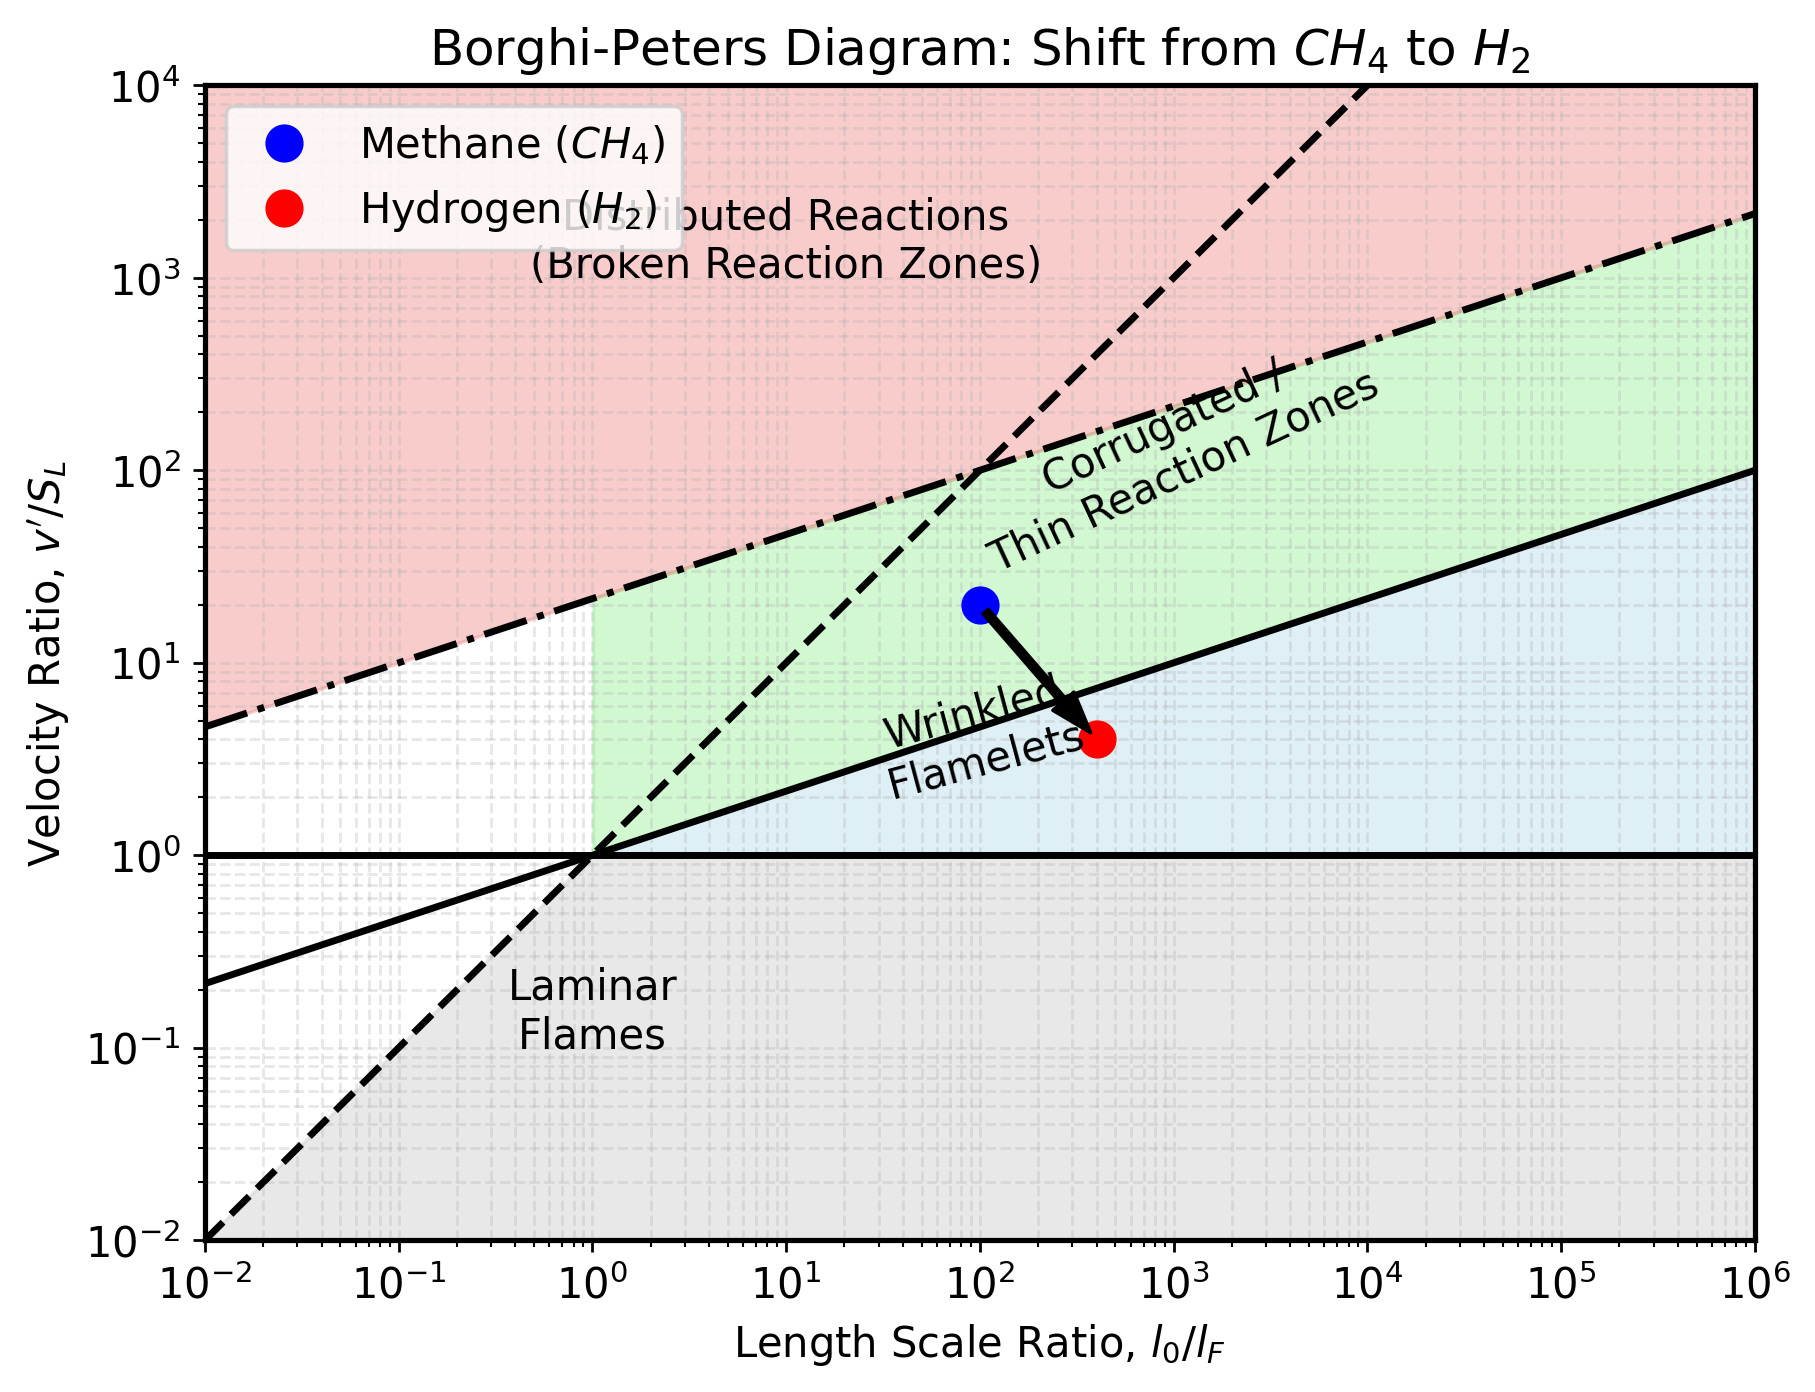

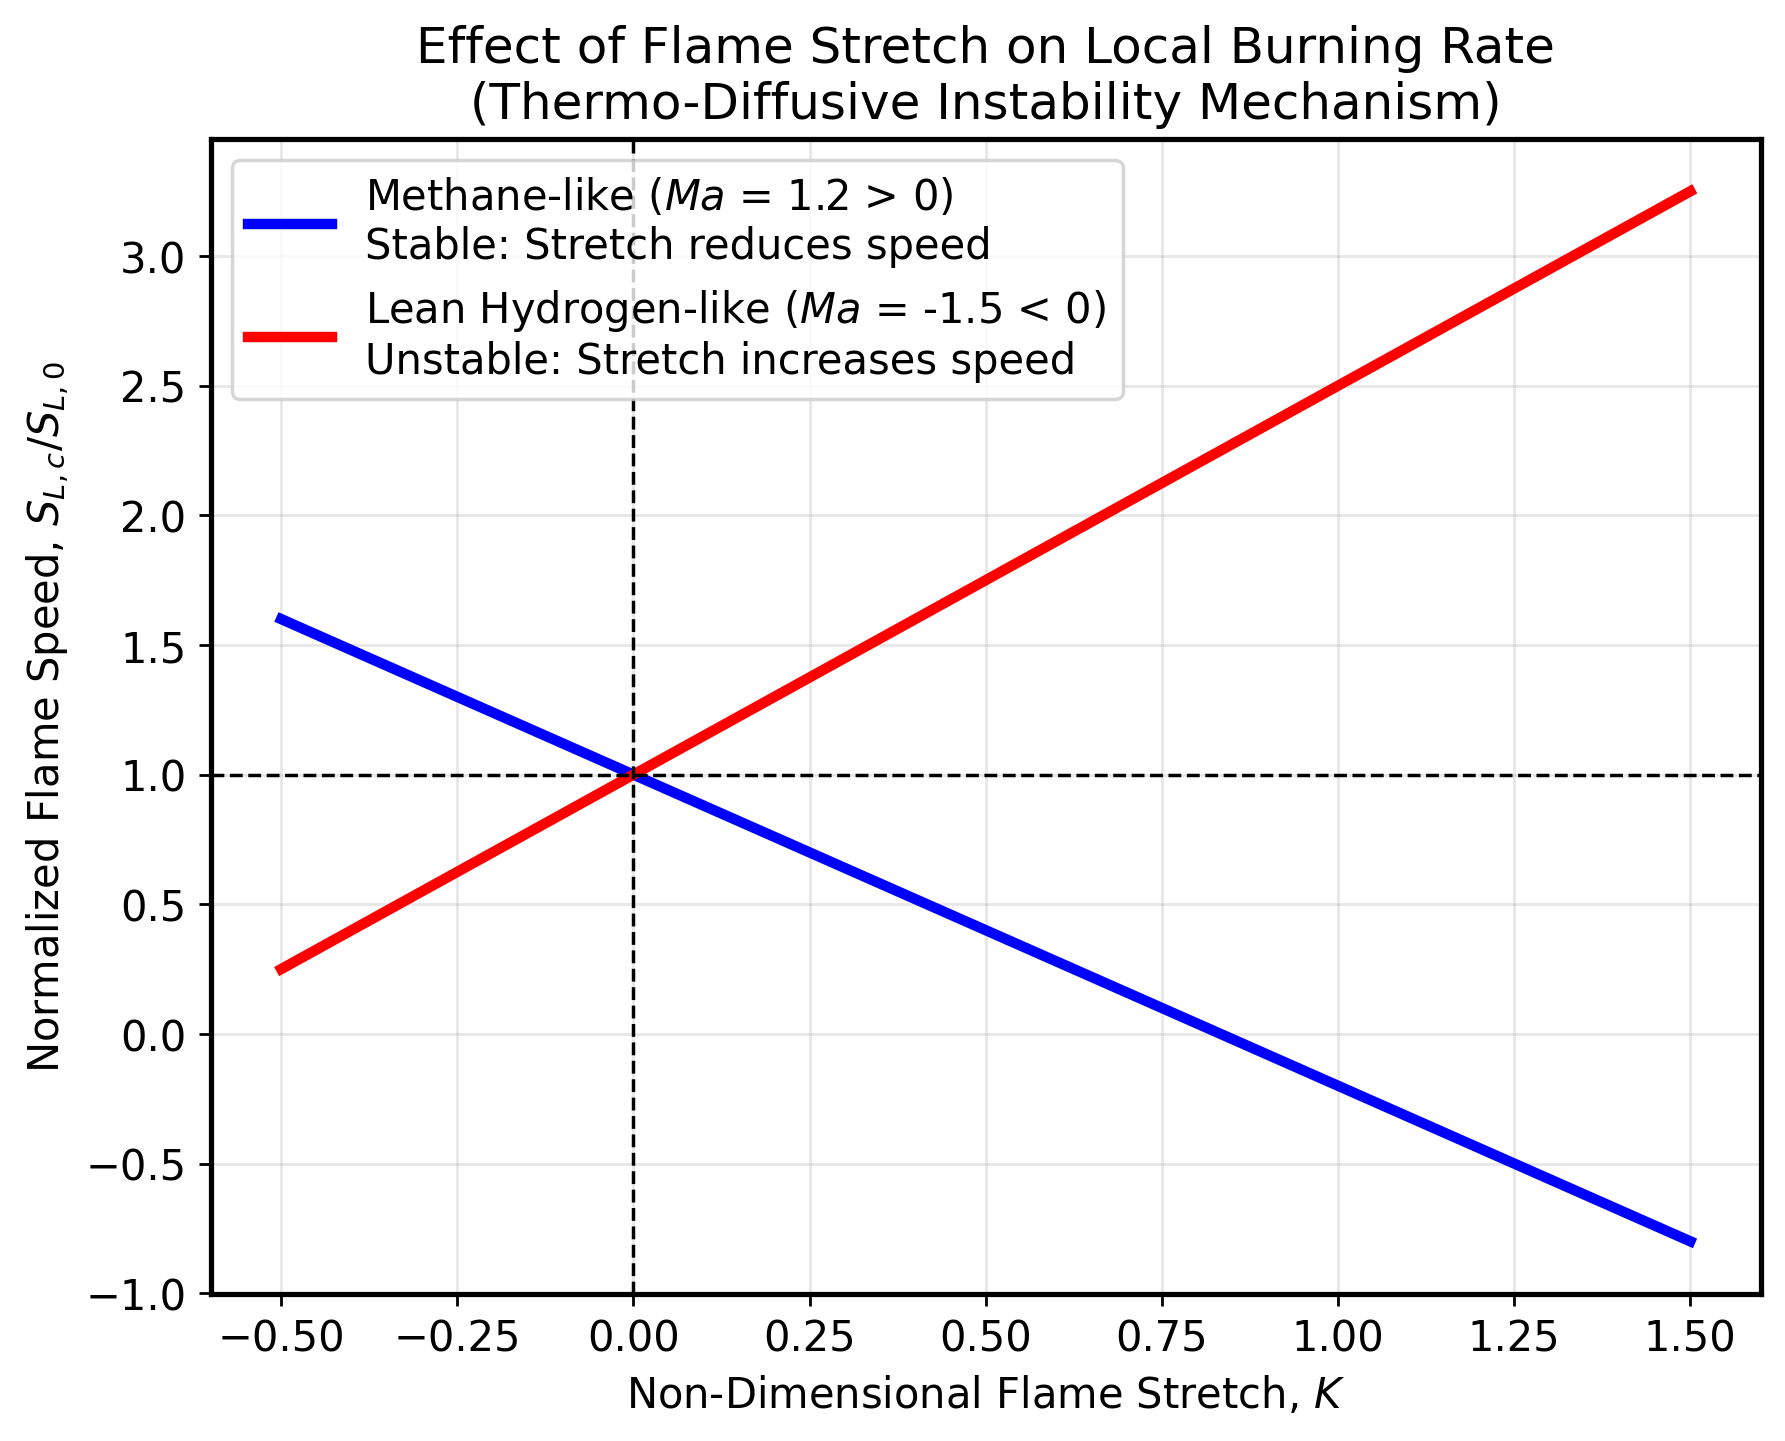

In [2]:
"""
Turbulent Combustion Diagnostic Plots: Borghi-Peters and Markstein Analysis.

This module generates PhD-level visualizations illustrating the turbulent
combustion regime shift from Methane (CH4) to Hydrogen (H2), alongside a
supplementary demonstration of thermo-diffusive instabilities driven by
flame stretch and negative Markstein numbers.

Usage:
    Run directly in Google Colaboratory.
    Ensure requirements are met. You can use uv or pip to install dependencies:
    !uv pip install numpy matplotlib
    # or
    # !pip install numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONTROL KNOBS & PARAMETERS
# ==========================================
# Display and Plotting Configurations
DPI: int = 250
plt.rcParams['figure.dpi'] = DPI
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.5

# Borghi-Peters Diagram Boundary Constraints
L_RATIO_MIN: float = 1e-2
L_RATIO_MAX: float = 1e6
V_RATIO_MIN: float = 1e-2
V_RATIO_MAX: float = 1e4

# Operating Points
# CH4 (Methane) Reference Base Point
CH4_L_RATIO: float = 1e2
CH4_V_RATIO: float = 2e1

# H2 (Hydrogen) Shifted Point Constraints
# SL increases ~5x -> v'/SL decreases by a factor of 5
# lF decreases ~4x -> l0/lF increases by a factor of 4
H2_L_RATIO: float = CH4_L_RATIO * 4.0
H2_V_RATIO: float = CH4_V_RATIO / 5.0

# Stretch / Markstein Analysis Parameters
K_MIN: float = -0.5
K_MAX: float = 1.5
MA_CH4: float = 1.2   # Methane (Le ~ 1)
MA_H2: float = -1.5   # Lean Hydrogen (Le << 1)

def plot_borghi_peters() -> None:
    """
    Generates and renders the Borghi-Peters regime diagram.
    Plots the operational shift from a baseline hydrocarbon to hydrogen.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Generate length scale domain
    l_ratio = np.logspace(np.log10(L_RATIO_MIN), np.log10(L_RATIO_MAX), 500)

    # Define Regime Demarcation Lines
    v_laminar = np.ones_like(l_ratio)                     # v'/SL = 1
    v_da1 = l_ratio                                       # Da = 1
    v_ka1 = l_ratio**(1/3)                                # Ka = 1
    v_ka100 = 100**(2/3) * l_ratio**(1/3)                 # Ka = 100

    # Plot Boundaries
    ax.plot(l_ratio, v_laminar, 'k-', linewidth=2)
    ax.plot(l_ratio, v_da1, 'k--', linewidth=2)
    ax.plot(l_ratio, v_ka1, 'k-', linewidth=2)
    ax.plot(l_ratio, v_ka100, 'k-.', linewidth=2)

    # Shade and Label Regimes
    ax.fill_between(l_ratio, V_RATIO_MIN, np.minimum(v_laminar, v_da1),
                    color='lightgrey', alpha=0.5)
    ax.text(1e0, 1e-1, 'Laminar\nFlames', fontsize=12, ha='center')

    ax.fill_between(l_ratio, v_laminar, v_ka1, where=(l_ratio > 1),
                    color='lightblue', alpha=0.4)
    ax.text(1e2, 2, 'Wrinkled\nFlamelets', fontsize=12, ha='center', rotation=15)

    ax.fill_between(l_ratio, v_ka1, v_ka100, where=(l_ratio > 1),
                    color='lightgreen', alpha=0.4)
    ax.text(1e3, 3e1, 'Corrugated /\nThin Reaction Zones',
            fontsize=12, ha='center', rotation=25)

    ax.fill_between(l_ratio, v_ka100, V_RATIO_MAX,
                    color='lightcoral', alpha=0.4)
    ax.text(1e1, 1e3, 'Distributed Reactions\n(Broken Reaction Zones)',
            fontsize=12, ha='center')

    # Plot Trajectory Shift Points
    ax.plot(CH4_L_RATIO, CH4_V_RATIO, 'bo', markersize=10, label=r'Methane ($CH_4$)')
    ax.plot(H2_L_RATIO, H2_V_RATIO, 'ro', markersize=10, label=r'Hydrogen ($H_2$)')
    ax.annotate('', xy=(H2_L_RATIO, H2_V_RATIO), xytext=(CH4_L_RATIO, CH4_V_RATIO),
                arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8))

    # Configure Axes
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim([L_RATIO_MIN, L_RATIO_MAX])
    ax.set_ylim([V_RATIO_MIN, V_RATIO_MAX])
    ax.set_xlabel(r'Length Scale Ratio, $l_0/l_F$')
    # FIX APPLIED HERE: Added 'r' before the string to denote a raw string
    ax.set_ylabel(r'Velocity Ratio, $v^\prime/S_L$')
    ax.set_title(r'Borghi-Peters Diagram: Shift from $CH_4$ to $H_2$')
    ax.legend(loc='upper left')
    ax.grid(True, which="both", ls="--", alpha=0.3)

    plt.show()

def plot_markstein_stretch() -> None:
    """
    Generates and renders the Markstein number / flame stretch sensitivity plot.
    Illustrates the thermo-diffusive instability fundamental to hydrogen combustion.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Generate non-dimensional stretch domain
    stretch_k = np.linspace(K_MIN, K_MAX, 100)

    # Compute Normalized Flame Speeds (SL_c / SL_0 = 1 - Ma * K)
    sl_ch4 = 1.0 - MA_CH4 * stretch_k
    sl_h2 = 1.0 - MA_H2 * stretch_k

    # Plot Stretch Responses
    ax.plot(stretch_k, sl_ch4, 'b-', linewidth=3,
            label=f'Methane-like ($Ma$ = {MA_CH4} > 0)\nStable: Stretch reduces speed')
    ax.plot(stretch_k, sl_h2, 'r-', linewidth=3,
            label=f'Lean Hydrogen-like ($Ma$ = {MA_H2} < 0)\nUnstable: Stretch increases speed')

    # Plot Reference Axes
    ax.axhline(1.0, color='k', linestyle='--', linewidth=1)
    ax.axvline(0.0, color='k', linestyle='--', linewidth=1)

    # Configure Axes
    ax.set_xlabel(r'Non-Dimensional Flame Stretch, $K$')
    ax.set_ylabel(r'Normalized Flame Speed, $S_{L,c} / S_{L,0}$')
    ax.set_title('Effect of Flame Stretch on Local Burning Rate\n'
                 '(Thermo-Diffusive Instability Mechanism)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.show()

if __name__ == '__main__':
    # Execute visualization generation
    plot_borghi_peters()
    plot_markstein_stretch()